# Introduction
In this notebook, I will perform exploratory data analysis (EDA) for my honours thesis on comparing computer vision technologies for sprint form analysis using ground truth markered videos.

# Required Libraries
First i'll download and import the necessary libraries.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from moviepy import VideoFileClip
import cv2
import mediapipe as mp
from ultralytics import YOLO

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Exploratory Testing

Set Up CV (Computer Vision) Technologies

In [2]:
# DataFrame to store angles
angles_columns = ['frame', 'left_elbow_angle', 'left_knee_angle', 'left_shoulder_angle', 'left_hip_angle', 'left_ankle_angle',
            'right_elbow_angle', 'right_knee_angle', 'right_shoulder_angle', 'right_hip_angle', 'right_ankle_angle']

points_columns = ['frame', 'left_elbow', 'left_knee', 'left_shoulder', 'left_hip', 'left_ankle', 'left_wrist','right_shoulder',
                   'right_elbow', 'right_wrist', 'right_hip', 'right_knee', 'right_ankle']


mp_angles_df = pd.DataFrame(columns=points_columns)
yolo_angles_df = pd.DataFrame(columns=points_columns)

TESTFILE = '../data/formatted/leftside/accel1-slowmo.mp4'

## MediaPipe

Details:

Uses OpenCV and Media Pipe to perform this introductory testing. OpenCV to read each frame in the video capturing each image in BGR format, converts it to RGB format for media pipe, which then detects the pose using the colors to then draw them using OpenCV

Notes:

From watching these videos get processed and estimate the pose, first thing i noticed is the inability to estimate if the target is too far.

It seems to estimate well, if the target is in well lit areas, wearting clothes that are contrasting to the environment.

Also issues with identifying the correct target when multiple people in the video

In [1]:
# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()
mp_drawing = mp.solutions.drawing_utils



# Function to process videos using MediaPipe Pose and calculate joint angles
def process_videos_with_mediapipe(side):
    formatted_side_path = os.path.join(formatted_path, side)
    
    # Iterate over files in the formatted side directory
    for filename in os.listdir(formatted_side_path):
        if filename.endswith('.mp4'):
            video_file_path = os.path.join(formatted_side_path, filename)
            process_single_video(video_file_path)

def process_single_video(video_file_path, mp_angles_df):
    cap = cv2.VideoCapture(video_file_path)
    
    if not cap.isOpened():
        print(f"Error opening video file {video_file_path}")
        return
    
    print(f"Processing video: {video_file_path}")

    frame_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert the frame to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Process the frame with MediaPipe Pose
        results = pose.process(frame_rgb)
        
        # Draw pose landmarks on the frame
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
            
            # Extract landmarks
            landmarks = results.pose_landmarks.landmark
            
            # Get coordinates for left side
            left_shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
            left_elbow = [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y]
            left_wrist = [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y]
            left_hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
            left_knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            left_ankle = [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y]
            left_foot_index = [landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].x, landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].y]

            # Get coordinates for right side
            right_shoulder = [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y]
            right_elbow = [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y]
            right_wrist = [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y]
            right_hip = [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y]
            right_knee = [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y]
            right_ankle = [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y]
            right_foot_index = [landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].y]

            # Get frame dimensions
            frame_width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
            frame_height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
            
            # Convert normalized coordinates to pixel positions
            left_shoulder = [(left_shoulder[0] * frame_width), (left_shoulder[1] * frame_height)]
            left_elbow = [(left_elbow[0] * frame_width), (left_elbow[1] * frame_height)]
            left_wrist = [(left_wrist[0] * frame_width), (left_wrist[1] * frame_height)]
            left_hip = [(left_hip[0] * frame_width), (left_hip[1] * frame_height)]
            left_knee = [(left_knee[0] * frame_width), (left_knee[1] * frame_height)]
            left_ankle = [(left_ankle[0] * frame_width), (left_ankle[1] * frame_height)]
            left_foot_index = [(left_foot_index[0] * frame_width), (left_foot_index[1] * frame_height)]
            
            right_shoulder = [(right_shoulder[0] * frame_width), (right_shoulder[1] * frame_height)]
            right_elbow = [(right_elbow[0] * frame_width), (right_elbow[1] * frame_height)]
            right_wrist = [(right_wrist[0] * frame_width), (right_wrist[1] * frame_height)]
            right_hip = [(right_hip[0] * frame_width), (right_hip[1] * frame_height)]
            right_knee = [(right_knee[0] * frame_width), (right_knee[1] * frame_height)]
            right_ankle = [(right_ankle[0] * frame_width), (right_ankle[1] * frame_height)]
            right_foot_index = [(right_foot_index[0] * frame_width), (right_foot_index[1] * frame_height)]

            # Store points into a DataFrame
            mp_angles_df = mp_angles_df.append({
                'frame': frame_count,
                'left_shoulder': left_shoulder,
                'left_elbow': left_elbow,
                'left_wrist': left_wrist,
                'left_hip': left_hip,
                'left_knee': left_knee,
                'left_ankle': left_ankle,
                'left_foot_index': left_foot_index,
                'right_shoulder': right_shoulder,
                'right_elbow': right_elbow,
                'right_wrist': right_wrist,
                'right_hip': right_hip,
                'right_knee': right_knee,
                'right_ankle': right_ankle,
                'right_foot_index': right_foot_index
            }, ignore_index=True)
            
            # # Calculate angles for left side
            # left_elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
            # left_knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
            # left_shoulder_angle = calculate_angle(left_hip, left_shoulder, left_elbow)
            # left_hip_angle = calculate_angle(left_shoulder, left_hip, left_knee)
            # left_ankle_angle = calculate_angle(left_knee, left_ankle, [left_ankle[0], left_ankle[1] + 0.1])  # Assuming vertical line for ankle
            
            # # Calculate angles for right side
            # right_elbow_angle = calculate_angle(right_shoulder, right_elbow, right_wrist)
            # right_knee_angle = calculate_angle(right_hip, right_knee, right_ankle)
            # right_shoulder_angle = calculate_angle(right_hip, right_shoulder, right_elbow)
            # right_hip_angle = calculate_angle(right_shoulder, right_hip, right_knee)
            # right_ankle_angle = calculate_angle(right_knee, right_ankle, [right_ankle[0], right_ankle[1] + 0.1])  # Assuming vertical line for ankle
            
            # # Display angles on the frame
            # cv2.putText(frame, str(left_elbow_angle), 
            #             tuple(np.multiply(left_elbow, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(left_knee_angle), 
            #             tuple(np.multiply(left_knee, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(left_shoulder_angle), 
            #             tuple(np.multiply(left_shoulder, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(left_hip_angle), 
            #             tuple(np.multiply(left_hip, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(left_ankle_angle), 
            #             tuple(np.multiply(left_ankle, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(right_elbow_angle), 
            #             tuple(np.multiply(right_elbow, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(right_knee_angle), 
            #             tuple(np.multiply(right_knee, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(right_shoulder_angle), 
            #             tuple(np.multiply(right_shoulder, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(right_hip_angle), 
            #             tuple(np.multiply(right_hip, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            # cv2.putText(frame, str(right_ankle_angle), 
            #             tuple(np.multiply(right_ankle, [frame.shape[1], frame.shape[0]]).astype(int)), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA
            #             )
            
            # # Append angles to DataFrame
            # mp_angles_df = mp_angles_df.append({
            #             'frame': frame_count,
            #             'left_elbow_angle': left_elbow_angle,
            #             'left_knee_angle': left_knee_angle,
            #             'left_shoulder_angle': left_shoulder_angle,
            #             'left_hip_angle': left_hip_angle,
            #             'left_ankle_angle': left_ankle_angle,
            #             'right_elbow_angle': right_elbow_angle,
            #             'right_knee_angle': right_knee_angle,
            #             'right_shoulder_angle': right_shoulder_angle,
            #             'right_hip_angle': right_hip_angle,
            #             'right_ankle_angle': right_ankle_angle
            #         }, ignore_index=True)

            frame_count += 1

        # Display the frame
        cv2.imshow('Frame', frame)
        
        # Press Q on keyboard to exit
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
    
    # Release the video capture object
    cap.release()
    cv2.destroyAllWindows()

    return mp_angles_df

# Process videos for each side using MediaPipe Pose
#for side in sides:
#    process_videos_with_mediapipe(side)

mp_angles_df = process_single_video(TESTFILE, mp_angles_df)


NameError: name 'mp' is not defined

# Yolo Ultralytics

In [4]:
# Initialize YOLO model
model = YOLO('yolov8n-pose.pt')  # You can choose other models like 'yolov8s-pose.pt', 'yolov8m-pose.pt', etc.


In [2]:

# Function to process a single video using YOLO and calculate joint angles
def process_single_video(video_file_path, yolo_angles_df):
    cap = cv2.VideoCapture(video_file_path)
    
    if not cap.isOpened():
        print(f"Error opening video file {video_file_path}")
        return
    
    print(f"Processing video: {video_file_path}")
    frame_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Perform pose estimation
        results = model(frame)
        
        
        # Draw pose landmarks on the frame
        for result in results:
            
            for keypoint in result.keypoints.xy.cpu().numpy()[0]:

                cv2.circle(frame, (int(keypoint[0]), int(keypoint[1])), 5, (0, 255, 0), -1)
        
        # Extract landmarks
        if len(results) > 0:
            result = results[0]
            keypoints = result.keypoints.xy.cpu().numpy()[0]
            keypoints = [[kp[0],kp[1]] for kp in keypoints]

            #These might not be the right indices for the joints
            # Get coordinates for left side
            left_shoulder = keypoints[5]
            left_elbow = keypoints[6]
            left_wrist = keypoints[7]
            left_hip = keypoints[11]
            left_knee = keypoints[12]
            left_ankle = keypoints[13]
            
            # Get coordinates for right side
            right_shoulder = keypoints[2]
            right_elbow = keypoints[3]
            right_wrist = keypoints[4]
            right_hip = keypoints[8]
            right_knee = keypoints[9]
            right_ankle = keypoints[10]
            
             # Store points into a DataFrame
            yolo_angles_df = yolo_angles_df.append({
                'frame': frame_count,
                'left_shoulder': left_shoulder,
                'left_elbow': left_elbow,
                'left_wrist': left_wrist,
                'left_hip': left_hip,
                'left_knee': left_knee,
                'left_ankle': left_ankle,
                'right_shoulder': right_shoulder,
                'right_elbow': right_elbow,
                'right_wrist': right_wrist,
                'right_hip': right_hip,
                'right_knee': right_knee,
                'right_ankle': right_ankle
            }, ignore_index=True)
            
            
            # # Calculate angles for left side
            # left_elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
            # left_knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
            # left_shoulder_angle = calculate_angle(left_hip, left_shoulder, left_elbow)
            # left_hip_angle = calculate_angle(left_shoulder, left_hip, left_knee)
            # left_ankle_angle = calculate_angle(left_knee, left_ankle, [left_ankle[0], left_ankle[1] + 0.1])  # Assuming vertical line for ankle
            
            # # Calculate angles for right side
            # right_elbow_angle = calculate_angle(right_shoulder, right_elbow, right_wrist)
            # right_knee_angle = calculate_angle(right_hip, right_knee, right_ankle)
            # right_shoulder_angle = calculate_angle(right_hip, right_shoulder, right_elbow)
            # right_hip_angle = calculate_angle(right_shoulder, right_hip, right_knee)
            # right_ankle_angle = calculate_angle(right_knee, right_ankle, [right_ankle[0], right_ankle[1] + 0.1])  # Assuming vertical line for ankle
            
            # # Append angles to DataFrame
            # yolo_angles_df = yolo_angles_df.append({
            #     'frame': frame_count,
            #     'left_elbow_angle': left_elbow_angle,
            #     'left_knee_angle': left_knee_angle,
            #     'left_shoulder_angle': left_shoulder_angle,
            #     'left_hip_angle': left_hip_angle,
            #     'left_ankle_angle': left_ankle_angle,
            #     'right_elbow_angle': right_elbow_angle,
            #     'right_knee_angle': right_knee_angle,
            #     'right_shoulder_angle': right_shoulder_angle,
            #     'right_hip_angle': right_hip_angle,
            #     'right_ankle_angle': right_ankle_angle
            # }, ignore_index=True)
        
        frame_count += 1
        
        # Display the frame
        cv2.imshow('Frame', frame)
        
        # Press Q on keyboard to exit
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
    
    # Release the video capture object
    cap.release()
    cv2.destroyAllWindows()
    
    return yolo_angles_df

# Function to process videos using YOLO and calculate joint angles
def process_videos_with_yolo(side):
    formatted_side_path = os.path.join(formatted_path, side)
    
    # Iterate over files in the formatted side directory
    for filename in os.listdir(formatted_side_path):
        if "accel2-slowmo" in filename and filename.endswith('.mp4'):
            video_file_path = os.path.join(formatted_side_path, filename)
            yolo_angles_df = process_single_video(video_file_path, yolo_angles_df)
    
    # Save the DataFrame to a CSV file
    yolo_angles_df.to_csv(f'angles_{side}.csv', index=False)
    print(f"Saved angles to angles_{side}.csv")

# Define the paths
formatted_path = 'data/formatted'
sides = ['frontside', 'backside', 'leftside', 'rightside']

# Process videos for each side using YOLO
# for side in sides:
#     process_videos_with_yolo(side)

yolo_angles_df = process_single_video(TESTFILE, yolo_angles_df)

NameError: name 'TESTFILE' is not defined

In [6]:
# Function to calculate the angle between three points
def calculate_angle(a, b, c):
    a = np.array(a)  # First point
    b = np.array(b)  # Mid point
    c = np.array(c)  # End point
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360.0 - angle
    
    return angle

In [ ]:

JOINTS = ['left_elbow', 'left_knee', 'left_shoulder', 'left_hip', 'left_ankle', 'left_wrist',
              'right_shoulder', 'right_elbow', 'right_wrist', 'right_hip', 'right_knee', 'right_ankle']

# Merge the DataFrames on the 'frame' column
merged_df = pd.merge(mp_angles_df, yolo_angles_df, on='frame', suffixes=('_mp', '_yolo'))

#print(merged_df)


Average distance for left_elbow: 138.22
Average distance for left_knee: 159.28
Average distance for left_shoulder: 19.97
Average distance for left_hip: 13.79
Average distance for left_ankle: 154.15
Average distance for left_wrist: 108.75
Average distance for right_shoulder: 1400.28
Average distance for right_elbow: 217.71
Average distance for right_wrist: 1512.12
Average distance for right_hip: 118.68
Average distance for right_knee: 168.97
Average distance for right_ankle: 333.80


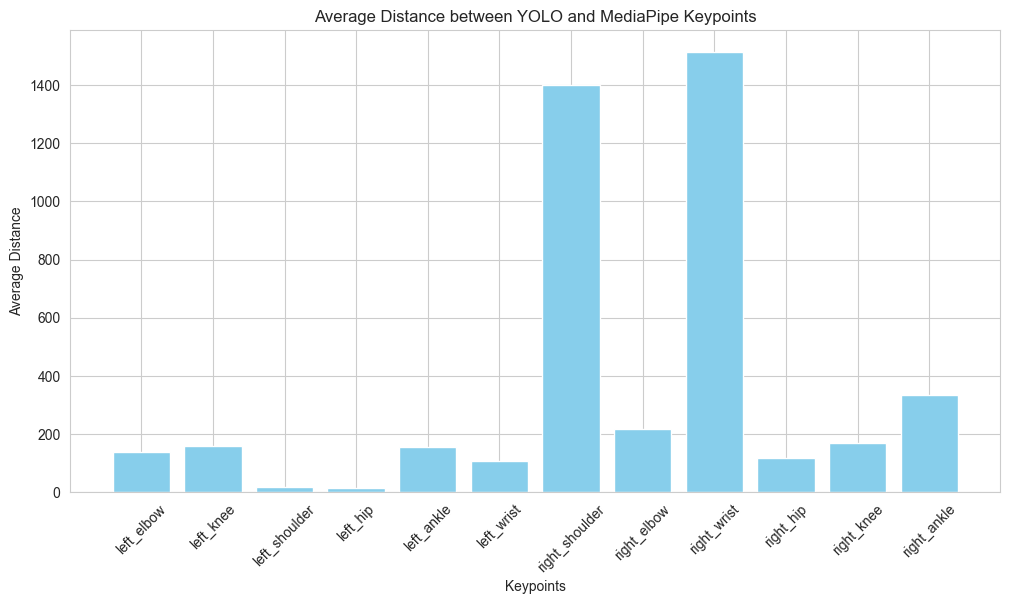

: 

In [ ]:
# Function to calculate Euclidean distance
def euclidean_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

# Calculate the distances between the corresponding keypoints
for point in ['left_elbow', 'left_knee', 'left_shoulder', 'left_hip', 'left_ankle', 'left_wrist',
              'right_shoulder', 'right_elbow', 'right_wrist', 'right_hip', 'right_knee', 'right_ankle']:
    merged_df[f'{point}_distance'] = merged_df.apply(lambda row: euclidean_distance(row[f'{point}_mp'], row[f'{point}_yolo']), axis=1)

# Calculate the average distance for each keypoint
average_distances = {}
for point in ['left_elbow', 'left_knee', 'left_shoulder', 'left_hip', 'left_ankle', 'left_wrist',
              'right_shoulder', 'right_elbow', 'right_wrist', 'right_hip', 'right_knee', 'right_ankle']:
    average_distances[point] = merged_df[f'{point}_distance'].mean()

# Print the average distances
for point, avg_distance in average_distances.items():
    print(f'Average distance for {point}: {avg_distance:.2f}')

# Plot the average distances
points = list(average_distances.keys())
distances = list(average_distances.values())

plt.figure(figsize=(12, 6))
plt.bar(points, distances, color='skyblue')
plt.xlabel('Keypoints')
plt.ylabel('Average Distance')
plt.title('Average Distance between YOLO and MediaPipe Keypoints')
plt.xticks(rotation=45)
plt.show()